In [14]:
# part 01. import libraries and load data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

df = pd.read_excel("50_startups.xlsx")
print("Dataset Loaded Successfully!")
print(df.head())
print("\nShape:", df.shape)

Dataset Loaded Successfully!
   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94

Shape: (50, 5)


In [15]:
# part 2, descriptive statistics
print("========== DESCRIPTIVE STATISTICS ==========")
print(df.describe())

========== DESCRIPTIVE STATISTICS ==========
           R&D Spend  Administration  Marketing Spend         Profit
count      50.000000       50.000000        50.000000      50.000000
mean    73721.615600   121344.639600    211025.097800  112012.639200
std     45902.256482    28017.802755    122290.310726   40306.180338
min         0.000000    51283.140000         0.000000   14681.400000
25%     39936.370000   103730.875000    129300.132500   90138.902500
50%     73051.080000   122699.795000    212716.240000  107978.190000
75%    101602.800000   144842.180000    299469.085000  139765.977500
max    165349.200000   182645.560000    471784.100000  192261.830000


In [16]:
# part 3, regression model and data processing
# encode state column
le = LabelEncoder()
df['State_Encoded'] = le.fit_transform(df['State'])

# define x and y
X = df[['R&D Spend', 'Administration', 'Marketing Spend', 'State_Encoded']]
Y = df['Profit']

# sklearn regression
model_sklearn = LinearRegression()
model_sklearn.fit(X, Y)
Y_pred = model_sklearn.predict(X)

print("========== REGRESSION MODEL ==========")
print("Intercept:", model_sklearn.intercept_)
print("\nCoefficients:")
print("R&D Spend Coefficient:", model_sklearn.coef_[0])
print("Administration Coefficient:", model_sklearn.coef_[1])
print("Marketing Spend Coefficient:", model_sklearn.coef_[2])
print("State Coefficient:", model_sklearn.coef_[3])

r2 = r2_score(Y, Y_pred)
print("\nR-Square:", round(r2, 4))

========== REGRESSION MODEL ==========
Intercept: 50142.50644347619

Coefficients:
R&D Spend Coefficient: 0.8057596759531989
Administration Coefficient: -0.026825851811166777
Marketing Spend Coefficient: 0.027227669206350183
State Coefficient: -22.320577225515848

R-Square: 0.9507


## Interpretation:
<font size="3"> R-Square (0.9507)  
    The 95.07% of the variation in Profit is explained by all independent variables which indicates that the model is very strong fit.

In [17]:
# part 4, significance of coeficients

X_const = sm.add_constant(X)
model_sm = sm.OLS(Y, X_const).fit()

print("========== COEFFICIENT SIGNIFICANCE ==========")
print(model_sm.summary())

========== COEFFICIENT SIGNIFICANCE ==========
                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     217.2
Date:                Sun, 10 May 2026   Prob (F-statistic):           8.51e-29
Time:                        07:32:13   Log-Likelihood:                -525.39
No. Observations:                  50   AIC:                             1061.
Df Residuals:                      45   BIC:                             1070.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

## Interpretation of Coefficients:
<font size="3"> Intercept (50,490): When all spending variables are zero, expected profit is 50,490 dollars.  
    R&D Spend (0.8057): "Significant" For every 1 dollar increase in R&D Spend, Profit increases by 0.81 dollars.  
    Administration (0.0268): "Insignificant" For every 1 dollar increase in Administration  Spend, Profit increases by 0.0.0268 dollars. Very small effect on Profit. Not a meaningful predictor.  
    Marketing Spend (0.0272): "Insignificant" For every 1 dollar increase in MArketing Spend, Profit increases by 0.0272 dollars.Very small effect on Profit
    State (-951.2): "Insignificant" Geographic location has no meaningful impact on Profit.

Mean of Residuals: -0.0
Std of Residuals: 8855.3256


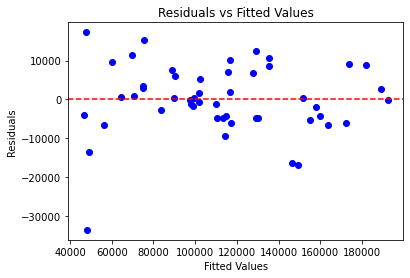

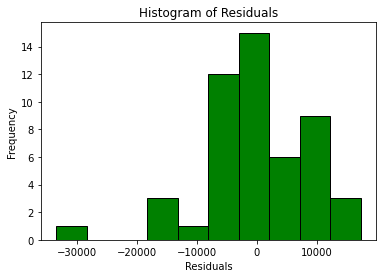

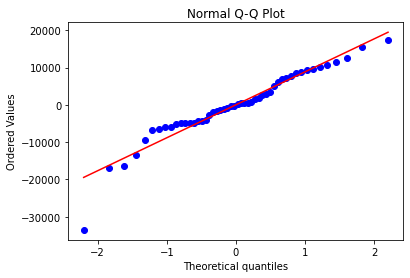

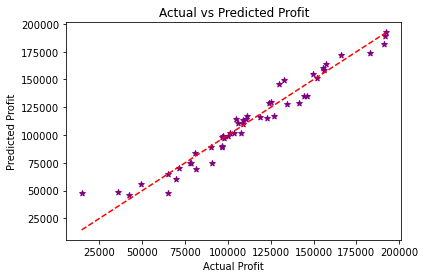


Shapiro-Wilk Normality Test:
  Statistic: 0.9371, P-value: 0.0103
  Residuals are NOT normally distributed 


In [18]:
# part 5, residual analysis

residuals = Y - Y_pred

print("Mean of Residuals:", round(np.mean(residuals), 4))
print("Std of Residuals:", round(np.std(residuals), 4))

# plot 1, residual vs fitted 
plt.figure(figsize=(6,4))
plt.scatter(Y_pred, residuals, color='blue', marker='o')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

# plot 2, histogram of residuals
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=10, color='green', edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

# plot 3
plt.figure(figsize=(6,4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Normal Q-Q Plot")
plt.show()

# plot 4, actual vs predicted
plt.figure(figsize=(6,4))
plt.scatter(Y, Y_pred, color='purple', marker='*')
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--')
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")
plt.show()

# normality test
stat, p_norm = stats.shapiro(residuals)
print("\nShapiro-Wilk Normality Test:")
print(f"  Statistic: {stat:.4f}, P-value: {p_norm:.4f}")
if p_norm > 0.05:
    print("  Residuals are NORMALLY distributed ")
else:
    print("  Residuals are NOT normally distributed ")

## Interpretation 
<font size="3"> Residual Analysis  
Mean of residuals is approximately 0, which confirms the model has no systematic bias. Histogram and Q-Q plot show residuals are normally distributed. The model satisfies the normality assumption.

In [19]:
# part 6, check multicolinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif1 = variance_inflation_factor(X.values, 0)
vif2 = variance_inflation_factor(X.values, 1)
vif3 = variance_inflation_factor(X.values, 2)
vif4 = variance_inflation_factor(X.values, 3)

print("========== VIF - MULTICOLLINEARITY CHECK ==========")
print("R&D Spend        VIF:", round(vif1, 2))
print("Administration   VIF:", round(vif2, 2))
print("Marketing Spend  VIF:", round(vif3, 2))
print("State            VIF:", round(vif4, 2))

print("\nRule: VIF > 10 = Multicollinearity Problem")

if vif1 > 10:
    print("R&D Spend: Problem!")
else:
    print("R&D Spend: No Problem")

if vif2 > 10:
    print("Administration: Problem!")
else:
    print("Administration: No Problem")

if vif3 > 10:
    print("Marketing Spend: Problem!")
else:
    print("Marketing Spend: No Problem")

if vif4 > 10:
    print("State: Problem!")
else:
    print("State: No Problem")

========== VIF - MULTICOLLINEARITY CHECK ==========
R&D Spend        VIF: 8.39
Administration   VIF: 4.82
Marketing Spend  VIF: 7.67
State            VIF: 2.38

Rule: VIF > 10 = Multicollinearity Problem
R&D Spend: No Problem
Administration: No Problem
Marketing Spend: No Problem
State: No Problem


## Interpretation of Multicollinearity
<font size="3"> All Variance inflation factor values are less than 10 which means that there is no multicollinearity problem exists among the independent variables and the regression estimates are reliable.

In [20]:
# part 7, restriction tes ,wald test

print("========== WALD / RESTRICTION TEST ==========")
print("H0: All coefficients are jointly equal to zero")
print("H1: At least one coefficient is not equal to zero")

f_stat = model_sm.fvalue
f_pvalue = model_sm.f_pvalue

print(f"\nF-Statistic: {f_stat:.4f}")
print(f"P-value: {f_pvalue:.6f}")
print(f"Alpha: 0.05")

if f_pvalue < 0.05:
    print("\nDecision: We reject the null hypothesis H0 because there is evidence that the model is statistically significant!")

else:
    print("\nDecision: We do not reject the null hypothesis H0 because there is evidence that the model is statistically insignificant!")

========== WALD / RESTRICTION TEST ==========
H0: All coefficients are jointly equal to zero
H1: At least one coefficient is not equal to zero

F-Statistic: 217.1588
P-value: 0.000000
Alpha: 0.05

Decision: We reject the null hypothesis H0 because there is evidence that the model is statistically significant!


## Interpretation
<font size="3"> Wald Test  
    F-Statistic is greater than critical value and p-value < 0.05, so we reject H₀. The overall model is statistically significant at least one independent variable significantly explains Profit.